In [1]:
from glob import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import hvplot.xarray
import holoviews as hv

# Create NAV files

In [4]:
#DATAMOR
time_start,time_end = pd.to_datetime('2023-03-07'), pd.to_datetime('2023-04-17')

files = glob('/home/datawork-lops-oc/MED/WEMSWOT/MET/*BATOS*.met')
files.sort()
ds_AT_met = xr.open_mfdataset(files)

ds_AT_met=ds_AT_met.sel(time = slice(time_start,time_end))
ds_AT_met['v_wind'] = ds_AT_met.trueairspeed*(-1.)*np.sin(np.pi/2.-ds_AT_met.trueairheading*np.pi/180.)
ds_AT_met['u_wind'] = ds_AT_met.trueairspeed*(-1.)*np.cos(np.pi/2.-ds_AT_met.trueairheading*np.pi/180.)

dir_AT_nav = '/home/datawork-lops-oc/MED/WEMSWOT/NAV/'
ds_AT_nav = xr.open_mfdataset(dir_AT_nav+'*shipnav*')
ds_AT_nav=ds_AT_nav.sel(time = slice(time_start,time_end))
ds_AT_met['lon'] = ds_AT_nav.long.interp_like(ds_AT_met.trueairspeed,method='nearest')
ds_AT_met['lat'] = ds_AT_nav.lat.interp_like(ds_AT_met.trueairspeed,method='nearest')

files = glob('/home/datawork-lops-oc/MED/CSWOT_2023/RAW/TECHSAS/NetCDF/MET/20230*TT_WEATHER.met')
files.sort()
ds_TT_met = xr.open_mfdataset(files)

ds_TT_met=ds_TT_met.sel(time = slice(time_start,time_end))
#ds_TT_met['trueairheading']=ds_TT_met.trueairheading.copy(data=ds_TT_met.trueairheading*0.+180.)
ds_TT_met['v_wind'] = -ds_TT_met.trueairspeed*np.sin(np.pi/2.-ds_TT_met.trueairheading*np.pi/180.)
ds_TT_met['u_wind'] = -ds_TT_met.trueairspeed*np.cos(np.pi/2.-ds_TT_met.trueairheading*np.pi/180.)

dir_TT_nav = '/home/datawork-lops-oc/MED/CSWOT_2023/RAW/TECHSAS/NetCDF/NAV/'
ds_TT_nav = xr.open_mfdataset(dir_TT_nav+'*shipnav*')
ds_TT_nav=ds_TT_nav.sel(time = slice(time_start,time_end))
ds_TT_met['lon'] = ds_TT_nav.long.interp_like(ds_TT_met.trueairspeed,method='nearest')
ds_TT_met['lat'] = ds_TT_nav.lat.interp_like(ds_TT_met.trueairspeed,method='nearest')

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


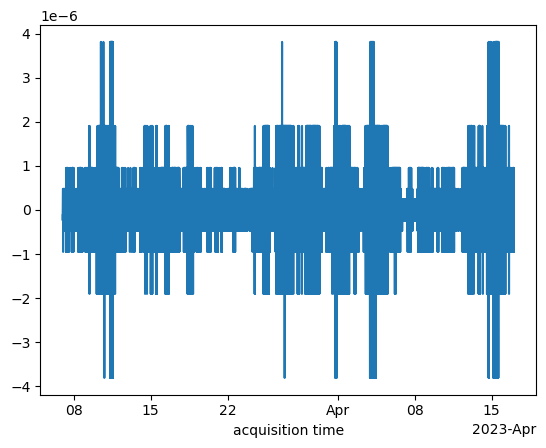

In [5]:
#check u_wind in knts
(np.sqrt(ds_TT_met.u_wind**2 + ds_TT_met.v_wind**2) - ds_TT_met.trueairspeed).plot()

In [6]:
ds_TT_met.to_netcdf('/home/datawork-lops-oc/aponte/margot/med_coloc/tethys_wind_nav.nc')
ds_AT_met.to_netcdf('/home/datawork-lops-oc/aponte/margot/med_coloc/atalante_wind_nav.nc')

PermissionError: [Errno 13] Permission denied: '/home/datawork-lops-oc/aponte/margot/med_coloc/tethys_wind_nav.nc'

# Load files 

In [8]:
# Local 
#ds_TT_met = xr.open_dataset('/Users/mdemol/DATA_WIND/tethys_wind_nav.nc')
#ds_AT_met = xr.open_dataset('/Users/mdemol/DATA_WIND/atalante_wind_nav.nc')
files = glob('/Users/mdemol/DATA_WIND/era5/adaptor.mars.internal-1725888040.2442634-4062-7-717f5d1f-4dbc-4297-ba65-42766024d861*.nc')
dsera = xr.open_mfdataset(files).rename({'longitude':'lon', 'latitude':'lat'})
arpege = glob('/Users/mdemol/DATA_WIND/arpege_hr/*.nc')
dsarp = xr.open_mfdataset(arpege).rename({'longitude':'lon', 'latitude':'lat', 'u10m':'u10', 'v10m':'v10'})
# Datarmor
#ds_TT_met = xr.open_dataset('/home/datawork-lops-oc/aponte/margot/med_coloc/tethys_wind_nav.nc')
#ds_AT_met= xr.open_dataset('/home/datawork-lops-oc/aponte/margot/med_coloc/atalante_wind_nav.nc')
#list_files = ['/home/ref-ecmwf/ERA5/2023/05','/home/ref-ecmwf/ERA5/2023/06','/home/ref-ecmwf/ERA5/2023/07','/home/ref-ecmwf/ERA5/2023/04',]
#fera = sorted(glob('/home/ref-ecmwf/ERA5/2023/03/*')) +sorted(glob('/home/ref-ecmwf/ERA5/2023/04/*'))
#dsera = xr.open_mfdataset(fera)[['u10', 'v10']].rename({'longitude025':'lon', 'latitude025':'lat'})

OSError: no files to open

# Colocalized

In [11]:
knts2ms = 0.514444
dstt = (ds_TT_met.set_coords(['lon', 'lat'])[['u_wind', 'v_wind']]*knts2ms)
dstt = dstt.where(dstt.lon.notnull(), drop=True).compute()
dsat = (ds_AT_met.set_coords(['lon', 'lat'])[['u_wind', 'v_wind']]*knts2ms).compute()

# hourly mean
dstt.coords['hour'] = (('time', ),pd.to_datetime(dstt.time).round('60min'))
dstt = dstt.reset_coords().groupby('hour').mean(dim='time').set_coords(['lon', 'lat']).rename({'hour':'time'})
dsat.coords['hour'] = (('time', ),pd.to_datetime(dsat.time).round('60min'))
dsat = dsat.reset_coords().groupby('hour').mean(dim='time').set_coords(['lon', 'lat']).rename({'hour':'time'})

dstt['U'] = np.sqrt(dstt.u_wind**2 + dstt.v_wind**2)
dsat['U'] = np.sqrt(dsat.u_wind**2 + dsat.v_wind**2)

In [12]:
ditt = dsera.interp(time = dstt.time, lon=dstt.lon, lat=dstt.lat).compute()
diat = dsera.interp(time = dsat.time, lon=dsat.lon, lat=dsat.lat).compute()
aitt = dsarp.interp(time = dstt.time, lon=dstt.lon, lat=dstt.lat).compute()
aiat = dsarp.interp(time = dsat.time, lon=dsat.lon, lat=dsat.lat).compute()
ditt['U'] = np.sqrt(ditt.u10**2 + ditt.v10**2)
diat['U'] = np.sqrt(diat.u10**2 + diat.v10**2)
aitt['U'] = np.sqrt(aitt.u10**2 + aitt.v10**2)
aiat['U'] = np.sqrt(aiat.u10**2 + aiat.v10**2)

________
# Geographical plot


In [8]:
df = ditt.to_dataframe()

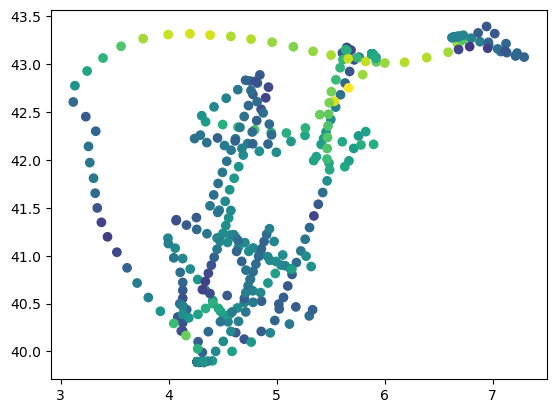

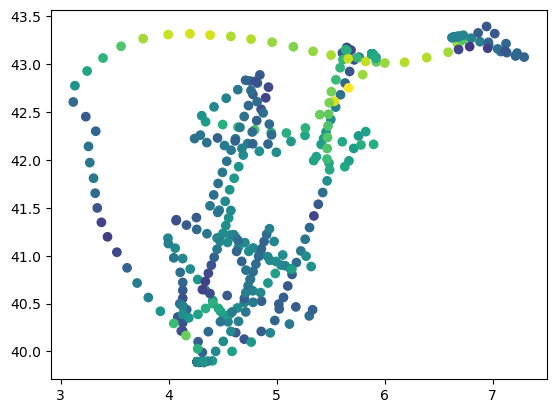

In [9]:
fig, ax = plt.subplots()
ax.scatter(x=ditt.lon, y=ditt.lat, c=ditt.u10)
fig

________
# Comparison on the ships trajectories


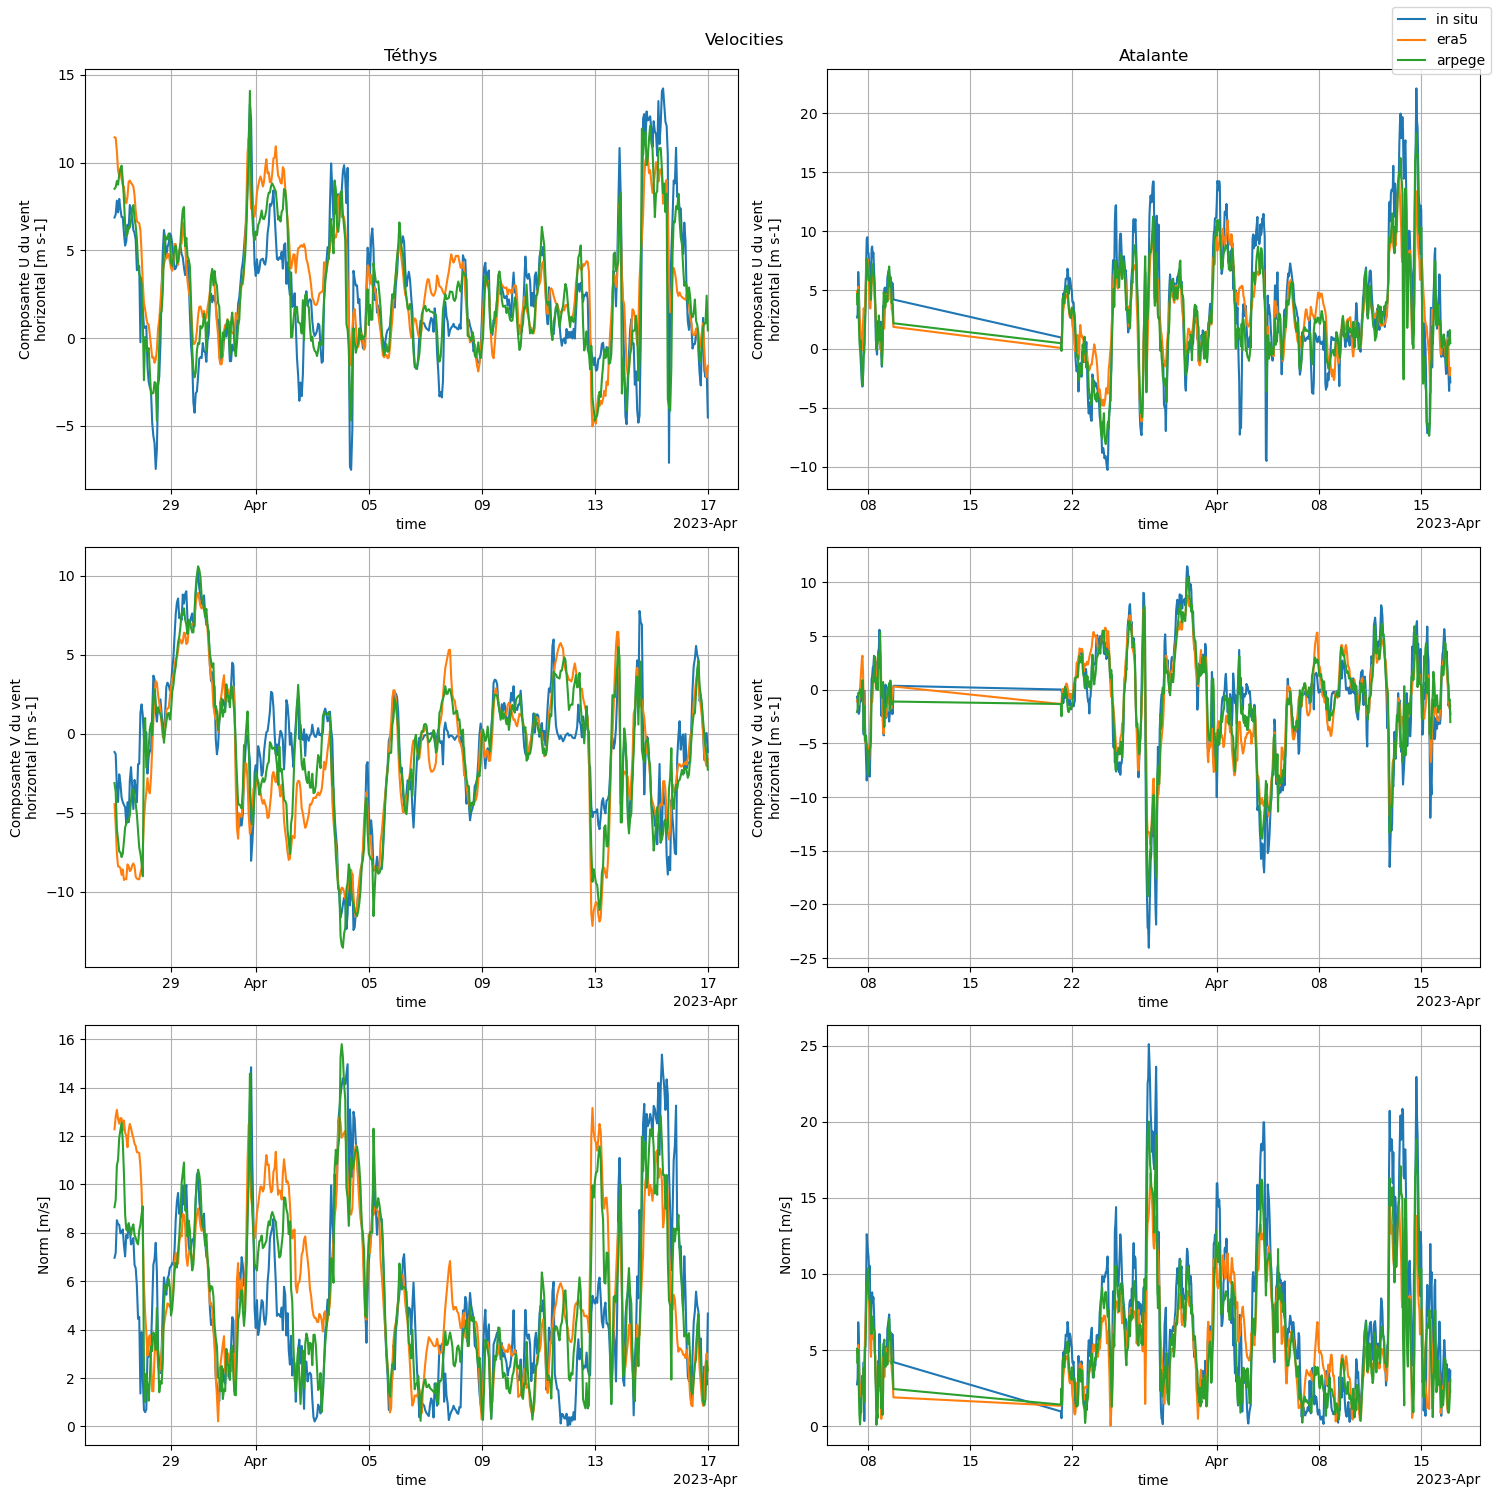

In [17]:
fig, axs = plt.subplots(3,2, figsize = (15,15))
axs = axs.flatten()

dstt.u_wind.plot(ax=axs[0], label='in situ')
ditt.u10.plot(ax=axs[0], label='era5')
aitt.u10.plot(ax=axs[0], label='arpege')

dsat.u_wind.plot(ax=axs[1])
diat.u10.plot(ax=axs[1])
aiat.u10.plot(ax=axs[1])

dstt.v_wind.plot(ax=axs[2])
ditt.v10.plot(ax=axs[2])
aitt.v10.plot(ax=axs[2])

dsat.v_wind.plot(ax=axs[3])
diat.v10.plot(ax=axs[3])
aiat.v10.plot(ax=axs[3])

dstt.U.plot(ax=axs[4])
ditt.U.plot(ax=axs[4])
aitt.U.plot(ax=axs[4])
axs[4].set_ylabel('Norm [m/s]')

dsat.U.plot(ax=axs[5])
diat.U.plot(ax=axs[5])
aiat.U.plot(ax=axs[5])
axs[5].set_ylabel('Norm [m/s]')
for ax in axs :
    ax.grid()

axs[0].set_title('Téthys')
axs[1].set_title('Atalante')

for ax in axs[2:]:
    ax.set_title('')
    
fig.suptitle('Velocities')
fig.tight_layout()
fig.legend()

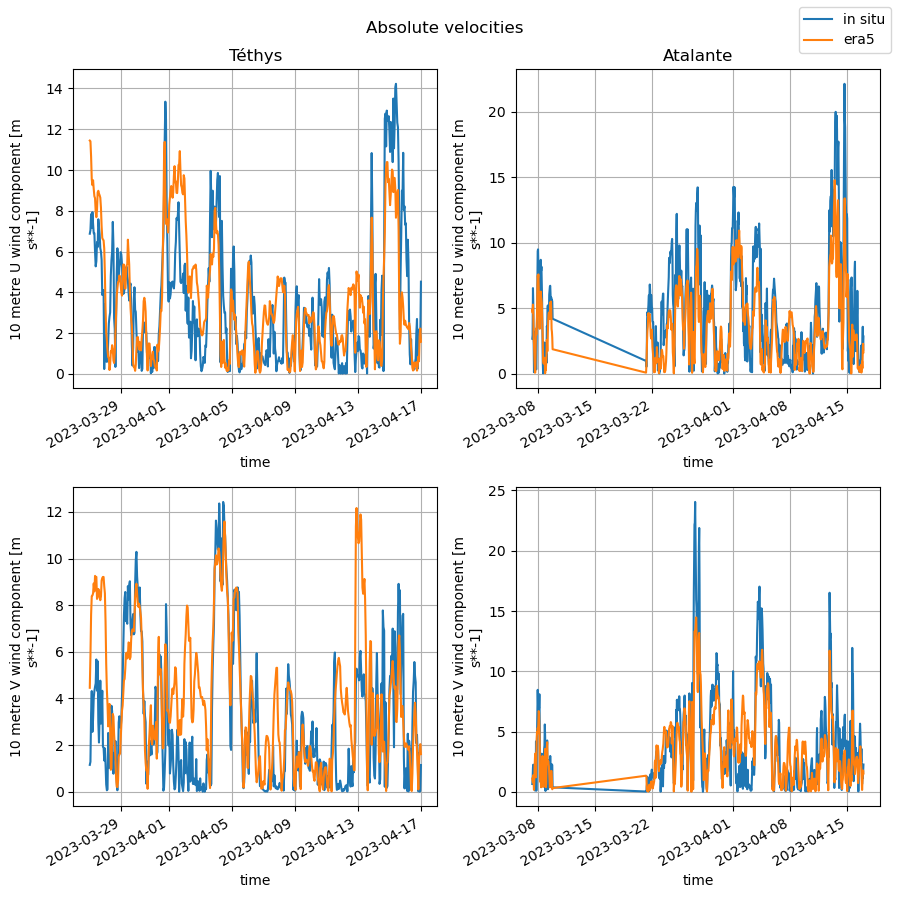

In [98]:
fig, axs = plt.subplots(2,2, figsize = (9,9))
axs = axs.flatten()

abs(dstt.u_wind).plot(ax=axs[0], label='in situ')
abs(ditt.u10).plot(ax=axs[0], label='era5')

abs(dsat.u_wind).plot(ax=axs[1])
abs(diat.u10).plot(ax=axs[1])

abs(dstt.v_wind).plot(ax=axs[2])
abs(ditt.v10).plot(ax=axs[2])

abs(dsat.v_wind).plot(ax=axs[3])
abs(diat.v10).plot(ax=axs[3])

for ax in axs :
    ax.grid()

axs[0].set_title('Téthys')
axs[1].set_title('Atalante')
fig.suptitle('Absolute velocities')
fig.tight_layout()
fig.legend()

# Difference distribution in situ ERA5

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_3309/3853739711.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend()


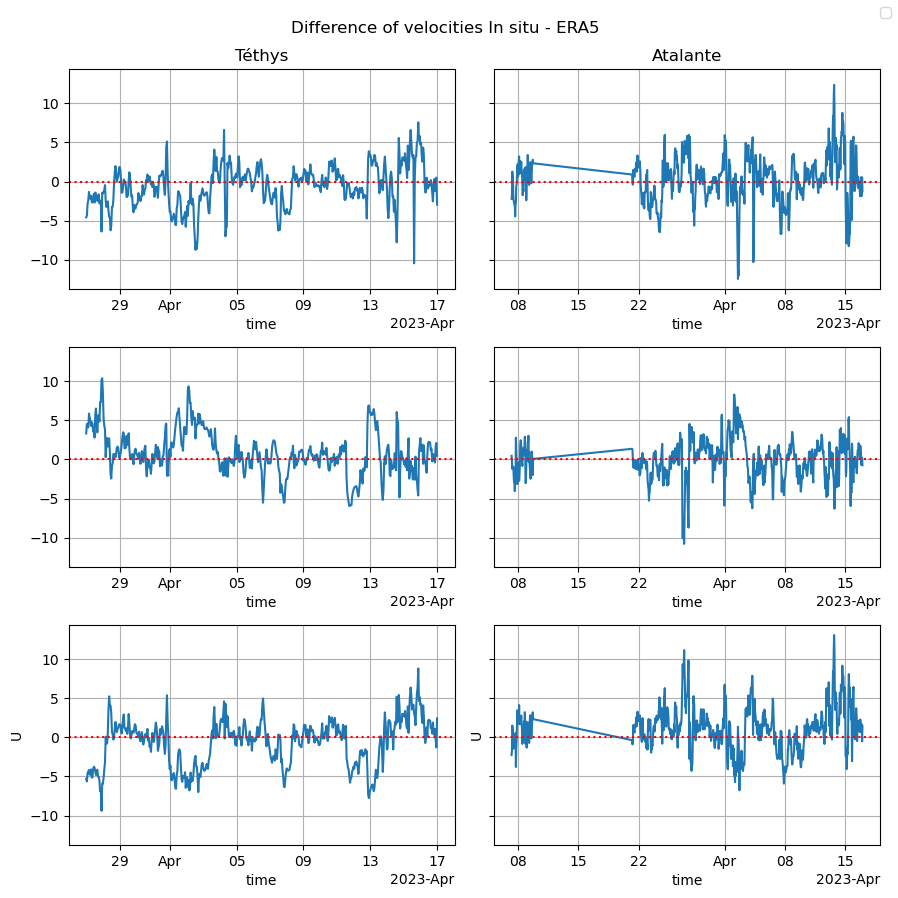

In [11]:
fig, axs = plt.subplots(3,2, figsize = (9,9), sharey = True)
axs = axs.flatten()

diff = [dstt.u_wind - ditt.u10, dsat.u_wind - diat.u10, dstt.v_wind - ditt.v10, dsat.v_wind - diat.v10, dstt.U - ditt.U, dsat.U - diat.U,] 
bins=np.arange(-10,10, 0.5)

for i in range(6):
    a = diff[i].plot(ax=axs[i])
    axs[i].axhline(0, ls=':', c='r')
    axs[i].grid()

axs[0].set_title('Téthys')
axs[1].set_title('Atalante')
fig.suptitle('Difference of velocities In situ - ERA5')
fig.tight_layout()
fig.legend()

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_3309/873724268.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend()


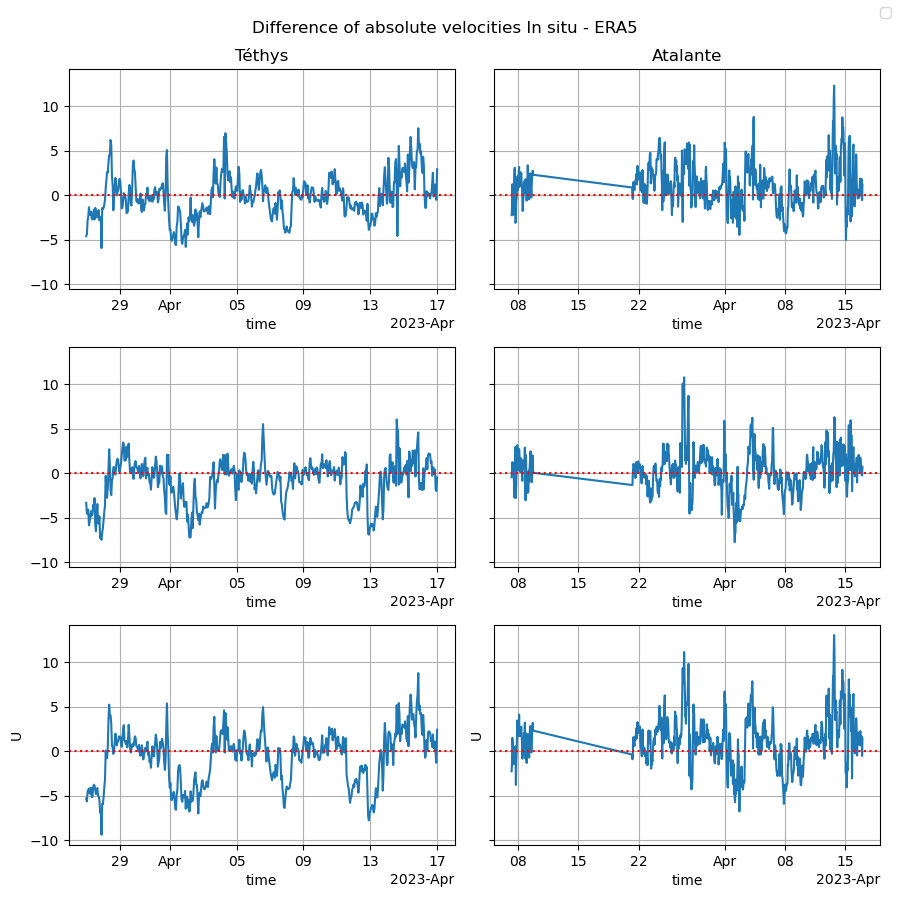

In [12]:
fig, axs = plt.subplots(3,2, figsize = (9,9), sharey = True)
axs = axs.flatten()

diff = [abs(dstt.u_wind) - abs(ditt.u10), abs(dsat.u_wind) - abs(diat.u10), abs(dstt.v_wind) - abs(ditt.v10), abs(dsat.v_wind) - abs(diat.v10), dstt.U - ditt.U, dsat.U - diat.U] 
bins=np.arange(-10,10, 0.5)

for i in range(6):
    a = diff[i].plot(ax=axs[i])
    axs[i].grid()
    axs[i].axhline(0, ls=':', c='r')

axs[0].set_title('Téthys')
axs[1].set_title('Atalante')
fig.suptitle('Difference of absolute velocities In situ - ERA5')
fig.tight_layout()
fig.legend()

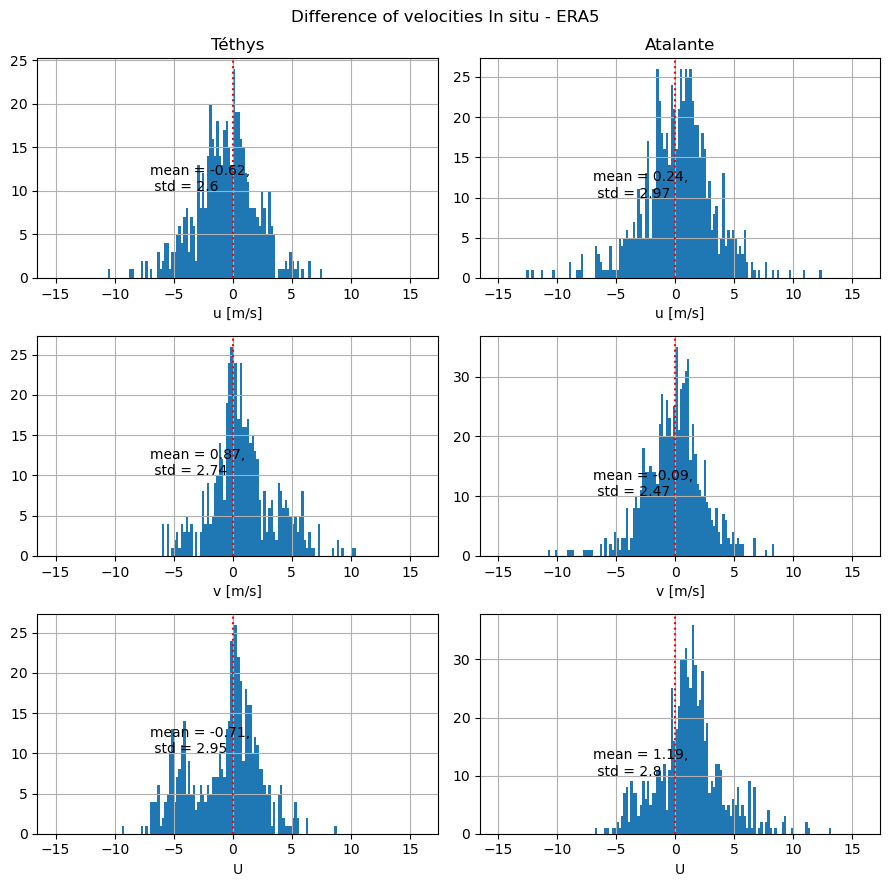

In [13]:
fig, axs = plt.subplots(3,2, figsize = (9,9))
axs = axs.flatten()
diff = [dstt.u_wind - ditt.u10, dsat.u_wind - diat.u10, dstt.v_wind - ditt.v10, dsat.v_wind - diat.v10, dstt.U - ditt.U, dsat.U - diat.U] 
bins=np.arange(-15,16, 0.2)

for i in range(6):
    a = diff[i].plot.hist(ax=axs[i], bins=bins)
    axs[i].grid()
    axs[i].text(-7,10, f'mean = {np.round(diff[i].mean().values, 2)},\n std = {np.round(diff[i].std().values, 2)}')
    axs[i].axvline(0, ls=':', c='r')

axs[0].set_xlabel('u [m/s]')
axs[2].set_xlabel('v [m/s]')
axs[1].set_xlabel('u [m/s]')
axs[3].set_xlabel('v [m/s]')

axs[0].set_title('Téthys')
axs[1].set_title('Atalante')
fig.suptitle('Difference of velocities In situ - ERA5')
fig.tight_layout()
#fig.legend()

# Difference distribution in situ ERA5

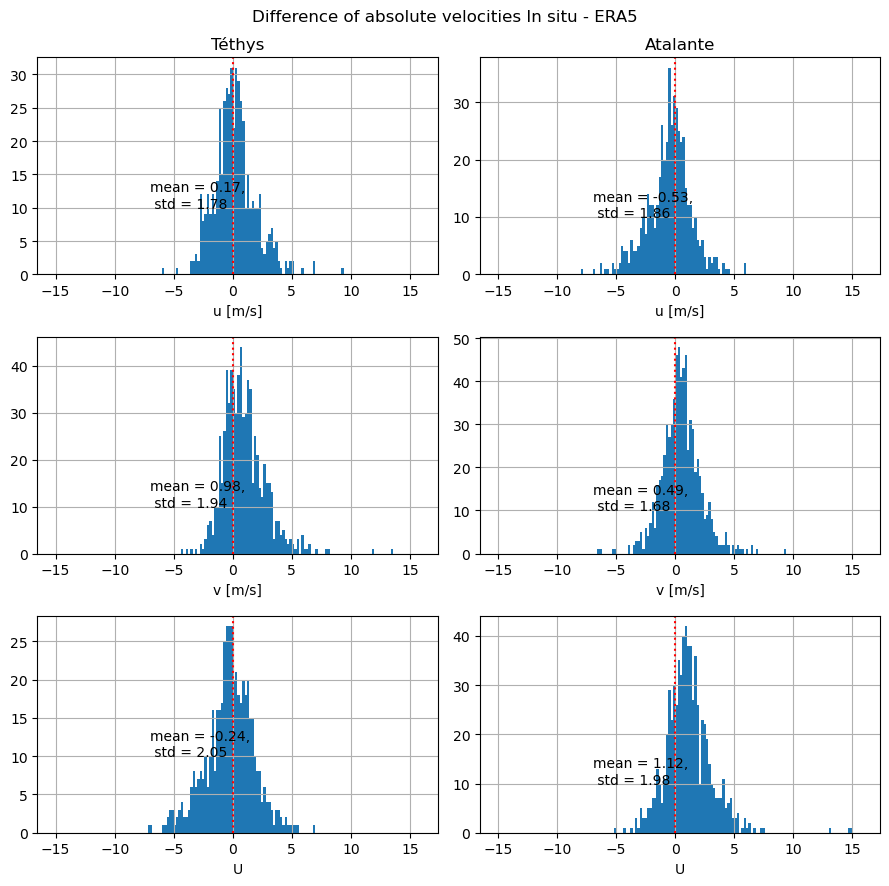

In [19]:
fig, axs = plt.subplots(3,2, figsize = (9,9))
axs = axs.flatten()
diff = [abs(dstt.u_wind) - abs(aitt.u10), abs(dstt.v_wind) - abs(aitt.v10), abs(dsat.u_wind) - abs(aiat.u10), abs(dsat.v_wind) - abs(aiat.v10), dstt.U - aitt.U, dsat.U - aiat.U] 
bins=np.arange(-15,16, 0.2)

for i in range(6):
    a = diff[i].plot.hist(ax=axs[i], bins=bins)
    axs[i].grid()
    axs[i].text(-7,10, f'mean = {np.round(diff[i].mean().values, 2)},\n std = {np.round(diff[i].std().values, 2)}')
    axs[i].axvline(0, ls=':', c='r')

axs[0].set_xlabel('u [m/s]')
axs[2].set_xlabel('v [m/s]')
axs[1].set_xlabel('u [m/s]')
axs[3].set_xlabel('v [m/s]')

for ax in axs[2:]:
    ax.set_title('')

axs[0].set_title('Téthys')
axs[1].set_title('Atalante')
fig.suptitle('Difference of absolute velocities In situ - ERA5')
fig.tight_layout()

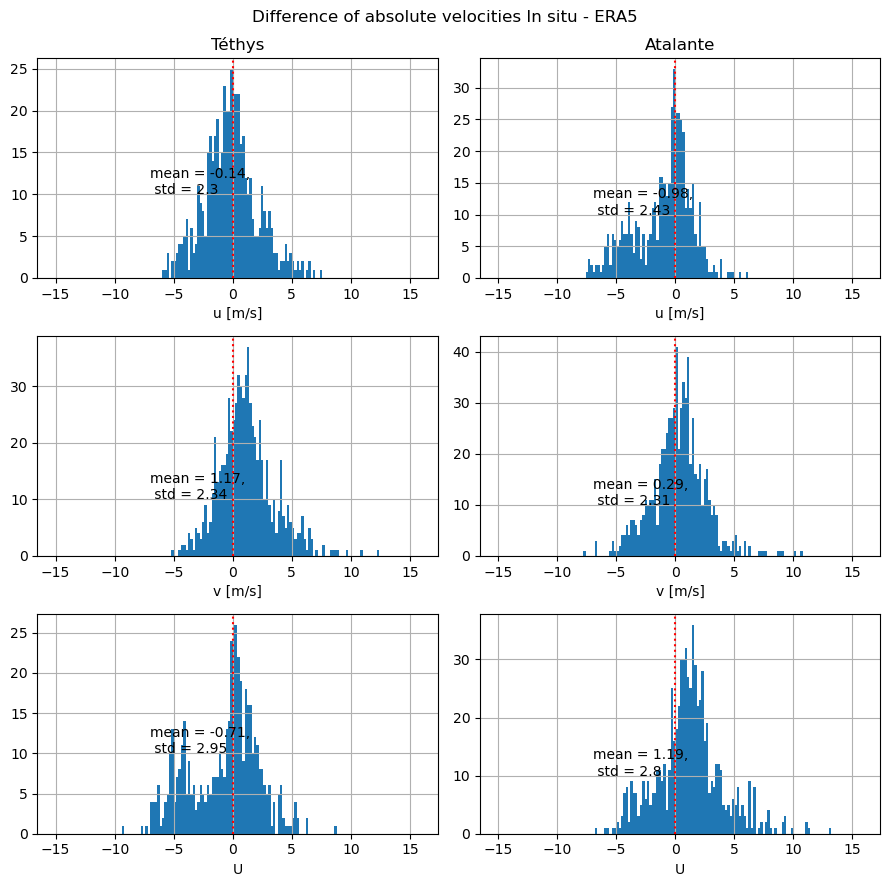

In [14]:
fig, axs = plt.subplots(3,2, figsize = (9,9))
axs = axs.flatten()
diff = [abs(dstt.u_wind) - abs(ditt.u10), abs(dstt.v_wind) - abs(ditt.v10), abs(dsat.u_wind) - abs(diat.u10), abs(dsat.v_wind) - abs(diat.v10), dstt.U - ditt.U, dsat.U - diat.U] 
bins=np.arange(-15,16, 0.2)

for i in range(6):
    a = diff[i].plot.hist(ax=axs[i], bins=bins)
    axs[i].grid()
    axs[i].text(-7,10, f'mean = {np.round(diff[i].mean().values, 2)},\n std = {np.round(diff[i].std().values, 2)}')
    axs[i].axvline(0, ls=':', c='r')

axs[0].set_xlabel('u [m/s]')
axs[2].set_xlabel('v [m/s]')
axs[1].set_xlabel('u [m/s]')
axs[3].set_xlabel('v [m/s]')

axs[0].set_title('Téthys')
axs[1].set_title('Atalante')
fig.suptitle('Difference of absolute velocities In situ - ERA5')
fig.tight_layout()

# Ratio distribution

Text(0.5, 0.98, 'In situ / ERA5')

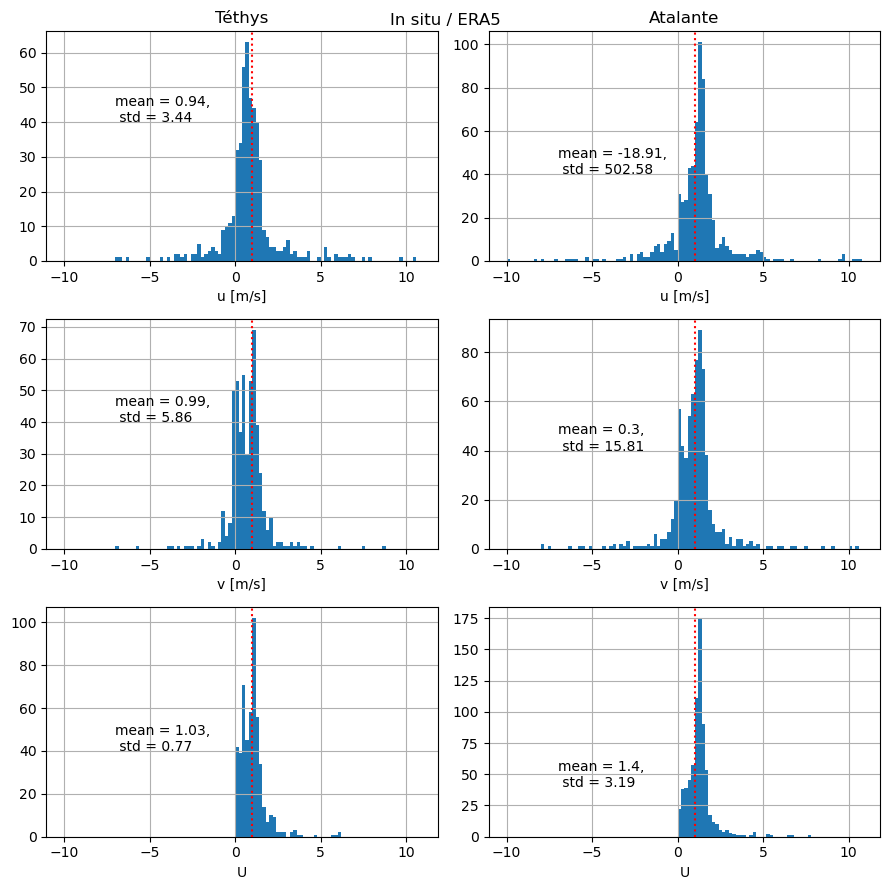

In [20]:
fig, axs = plt.subplots(3,2, figsize = (9,9))
axs = axs.flatten()
ratio = [dstt.u_wind/ditt.u10, dsat.u_wind/diat.u10, dstt.v_wind/ditt.v10, dsat.v_wind/diat.v10, dstt.U /ditt.U, dsat.U/diat.U] 
bins=np.arange(-10,11, 0.2)

for i in range(6):
    a = ratio[i].plot.hist(ax=axs[i], bins=bins)
    axs[i].grid()
    axs[i].text(-7,40, f'mean = {np.round(ratio[i].mean().values, 2)},\n std = {np.round(ratio[i].std().values, 2)}')
    axs[i].axvline(1, ls=':', c='r')

axs[0].set_xlabel('u [m/s]')
axs[2].set_xlabel('v [m/s]')
axs[1].set_xlabel('u [m/s]')
axs[3].set_xlabel('v [m/s]')

for ax in axs[2:]:
    ax.set_title('')
    
axs[0].set_title('Téthys')
axs[1].set_title('Atalante')
fig.tight_layout()
fig.suptitle('In situ / ERA5')
#fig.legend()

In [16]:
it, ie = 0,300000
dsat_ = dsat.isel(time = slice(it,ie))
dstt_ = dstt.isel(time = slice(it,ie))
diat_ = diat.isel(time = slice(it,ie))
ditt_ = ditt.isel(time = slice(it,ie))

layout = (dstt_.u_wind.hvplot(x='time', ax=axs[0], label='in situ', kind ='scatter') * ditt_.u10.hvplot(x='time',ax=axs[0], label='era5', kind ='scatter') 
          + dsat_.u_wind.hvplot(x='time',ax=axs[1], kind ='scatter') * diat_.u10.hvplot(x='time',ax=axs[1], kind ='scatter')
          + dstt_.v_wind.hvplot(x='time',ax=axs[2], kind ='scatter') * ditt_.v10.hvplot(x='time',ax=axs[2], kind ='scatter')
          + dsat_.v_wind.hvplot(x='time',ax=axs[3], kind ='scatter') * diat_.v10.hvplot(x='time',ax=axs[3], kind ='scatter')
         ).cols(2)
layout


:Layout
   .Overlay.I   :Overlay
      .Scatter.In_situ :Scatter   [time]   (u_wind)
      .Scatter.Era5    :Scatter   [time]   (10 metre U wind component)
   .Overlay.II  :Overlay
      .Scatter.I  :Scatter   [time]   (u_wind)
      .Scatter.II :Scatter   [time]   (10 metre U wind component)
   .Overlay.III :Overlay
      .Scatter.I  :Scatter   [time]   (v_wind)
      .Scatter.II :Scatter   [time]   (10 metre V wind component)
   .Overlay.IV  :Overlay
      .Scatter.I  :Scatter   [time]   (v_wind)
      .Scatter.II :Scatter   [time]   (10 metre V wind component)